# 9. Panorama Object Detection

For a selected tile:
1. Load the panorama image and camera pose (notebook 8 output)
2. Project labeled LiDAR cluster centroids onto the panorama to verify alignment
3. Extract perspective patches and run YOLOv8 detection
4. Backproject detections to 3D via AHN ground-plane ray casting
5. Cross-reference panorama detections with existing LiDAR clusters
6. Export detections as GeoJSON

In [11]:
import json
import sys
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

sys.path.insert(0, str(Path.cwd()))
import config
from utils.labels import Labels          # import the class, not the module
from utils.panorama_api import download_panorama_image
from utils.panorama_geometry import (
    CameraPose, lidar_points_to_pixels, equirect_to_perspective,
    make_patches, patch_bbox_to_equirect, detection_to_ground_position,
)
from utils.detection import (
    load_detector, detect_patches, cross_reference, detections_to_geodataframe,
    SKIP_LIDAR_LABELS,
)


## Configuration

In [12]:
TILECODES      = config.SETUP_TILECODES   # tiles to process in the batch run below
TILECODE       = TILECODES[0]             # example tile for per-panorama steps A-F
PANORAMA_IDX   = 0                        # which panorama for per-panorama steps A-F
PANO_DIR       = Path("data/input/panoramas")
YOLO_WEIGHTS   = "yolov8m.pt"
DETECTION_CONF = 0.35
MATCH_RADIUS_M = 2.5
CAM_HEIGHT_M   = 2.0   # Cyclomedia camera is ~2 m above the road surface

N_PATCHES  = 4      # 4 × 90° = full 360°
FOV_H      = 90.0
PATCH_SIZE = (640, 640)

print(f"Batch: {len(TILECODES)} tiles. Example tile for steps A-F: {TILECODE}")

Batch: 9 tiles. Example tile for steps A-F: 120300_489300


## Load panorama

In [13]:
import json

# Load all panoramas for this tile and pick one by index
pano_list_path = PANO_DIR / TILECODE / "panoramas.json"
assert pano_list_path.exists(), (
    f"No panoramas.json found for {TILECODE}. Run notebook 8 first."
)
with open(pano_list_path) as f:
    all_poses = json.load(f)

print(f"{len(all_poses)} panoramas available for tile {TILECODE}:")
for i, p in enumerate(all_poses):
    marker = " ◀ selected" if i == PANORAMA_IDX else ""
    print(f"  [{i}] {p['pano_id']}  "
          f"({p['x_rd']:.0f}, {p['y_rd']:.0f})  "
          f"heading={p['heading']:.1f}°{marker}")

pose_dict = all_poses[PANORAMA_IDX]
pose = CameraPose(
    x_rd=pose_dict["x_rd"],
    y_rd=pose_dict["y_rd"],
    z=pose_dict["z_wgs84"],
    heading=pose_dict["heading"],
    pitch=pose_dict["pitch"],
    roll=pose_dict.get("roll", 0.0),
)

img_path = PANO_DIR / TILECODE / f"{pose_dict['pano_id']}.jpg"
assert img_path.exists(), f"Image not found: {img_path}"
img_arr = np.array(Image.open(img_path).convert("RGB"))
H_pano, W_pano = img_arr.shape[:2]
print(f"\nLoaded: {img_path.name}  {W_pano}×{H_pano}")
print(f"Heading: {pose.heading:.1f}°  Pitch: {pose.pitch:.2f}°")


5 panoramas available for tile 120300_489300:
  [0] recording_2024-09-11_11-32-11_01531  (120358, 489349)  heading=350.4° ◀ selected
  [1] recording_2024-09-11_11-32-11_01567  (120360, 489329)  heading=155.5°
  [2] recording_2024-09-11_11-32-11_01535  (120354, 489369)  heading=349.6°
  [3] recording_2024-10-16_06-25-31_01335  (120346, 489321)  heading=240.9°
  [4] recording_2024-10-16_06-25-31_01328  (120378, 489333)  heading=259.0°

Loaded: recording_2024-09-11_11-32-11_01531.jpg  4000×2000
Heading: 350.4°  Pitch: 0.00°


## Step A — Project LiDAR cluster centroids onto the panorama

Sanity check: labeled clusters should appear near the correct objects in the image.

Loaded 57 clusters  (label col: 'label')


/var/folders/xm/kv_h3z3j6113q49b_8lb9xdh0000gn/T/ipykernel_20584/865008760.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", 20)


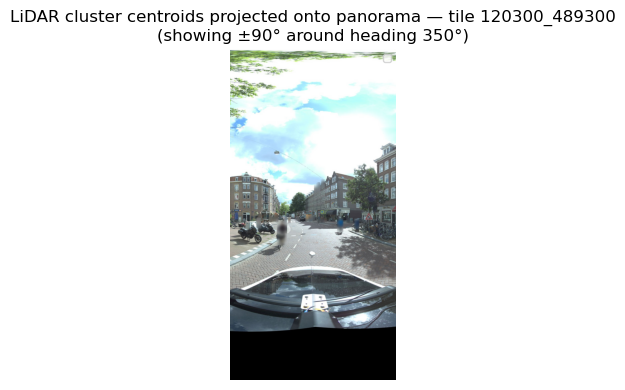

In [14]:
# Inventory path: try top-level first (notebook 4 output), then tile subdirectory
inv_path = config.CLUSTERS_DIR / f"inventory_{TILECODE}.csv"
if not inv_path.exists():
    inv_path = config.CLUSTERS_DIR / TILECODE / f"inventory_{TILECODE}.csv"

if not inv_path.exists():
    print(f"No cluster inventory found. Run notebooks 3.5 and 4 first.")
    cluster_df = pd.DataFrame()
else:
    cluster_df = pd.read_csv(inv_path)
    # Use final_label when manually corrected, otherwise fall back to auto label
    label_col = "final_label" if cluster_df.get("final_label", pd.Series()).notna().any() else "label"
    print(f"Loaded {len(cluster_df)} clusters  (label col: '{label_col}')")

if len(cluster_df) > 0:
    label_col = "final_label" if cluster_df.get("final_label", pd.Series()).notna().any() else "label"
    vis_df = cluster_df[~cluster_df[label_col].isin(SKIP_LIDAR_LABELS)].copy()

    cluster_ground_z = pose.z - CAM_HEIGHT_M
    xyz = np.column_stack([
        vis_df["centroid_x"].values,
        vis_df["centroid_y"].values,
        np.full(len(vis_df), cluster_ground_z),
    ])
    uv = lidar_points_to_pixels(xyz, pose, img_arr.shape)

    h_center = int(pose.heading / 360.0 * W_pano)
    half_w   = W_pano // 4
    u_start  = (h_center - half_w // 2) % W_pano
    u_end    = (h_center + half_w // 2) % W_pano

    if u_end > u_start:
        strip    = img_arr[:, u_start:u_end]
        u_offset = u_start
    else:
        strip    = np.concatenate([img_arr[:, u_start:], img_arr[:, :u_end]], axis=1)
        u_offset = u_start

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.imshow(strip)

    cmap = plt.cm.get_cmap("tab20", 20)
    for i, (u, v) in enumerate(uv):
        u_local = (u - u_offset) % W_pano
        if 0 <= u_local < strip.shape[1] and 0 <= v < H_pano:
            lbl  = int(vis_df.iloc[i][label_col])
            name = Labels.STR_DICT.get(lbl, str(lbl))
            ax.plot(u_local, v, "o", markersize=6,
                    color=cmap(lbl % 20), label=name)

    handles, lbls = ax.get_legend_handles_labels()
    by_label = dict(zip(lbls, handles))
    ax.legend(by_label.values(), by_label.keys(), loc="upper right", fontsize=7)
    ax.set_title(f"LiDAR cluster centroids projected onto panorama — tile {TILECODE}\n"
                 f"(showing ±90° around heading {pose.heading:.0f}°)")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


## Step B — Extract perspective patches

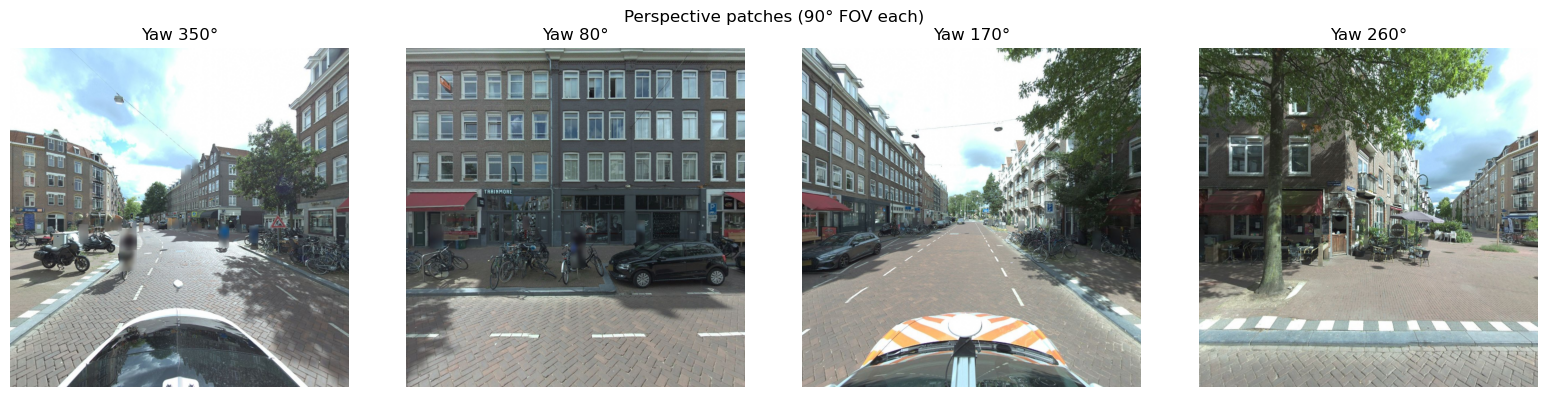

In [15]:
from utils.panorama_geometry import PatchParams

N_PATCHES = 4       # 4 patches × 90° FOV = full 360°
FOV_H = 90.0
PATCH_SIZE = (640, 640)

patch_params_list = make_patches(
    heading_deg=pose.heading,
    fov_h_deg=FOV_H,
    out_hw=PATCH_SIZE,
    n_horizontal=N_PATCHES,
    pitch_deg=0.0,
    img_shape=img_arr.shape,
)

img_patches = [equirect_to_perspective(img_arr, pp) for pp in patch_params_list]

fig, axes = plt.subplots(1, N_PATCHES, figsize=(16, 4))
for ax, patch, pp in zip(axes, img_patches, patch_params_list):
    ax.imshow(patch)
    ax.set_title(f"Yaw {pp.yaw_deg:.0f}°")
    ax.axis("off")
plt.suptitle("Perspective patches (90° FOV each)")
plt.tight_layout()
plt.show()


## Step C — YOLOv8 detection

Found 36 detections.


/var/folders/xm/kv_h3z3j6113q49b_8lb9xdh0000gn/T/ipykernel_20584/3219235122.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", 10)


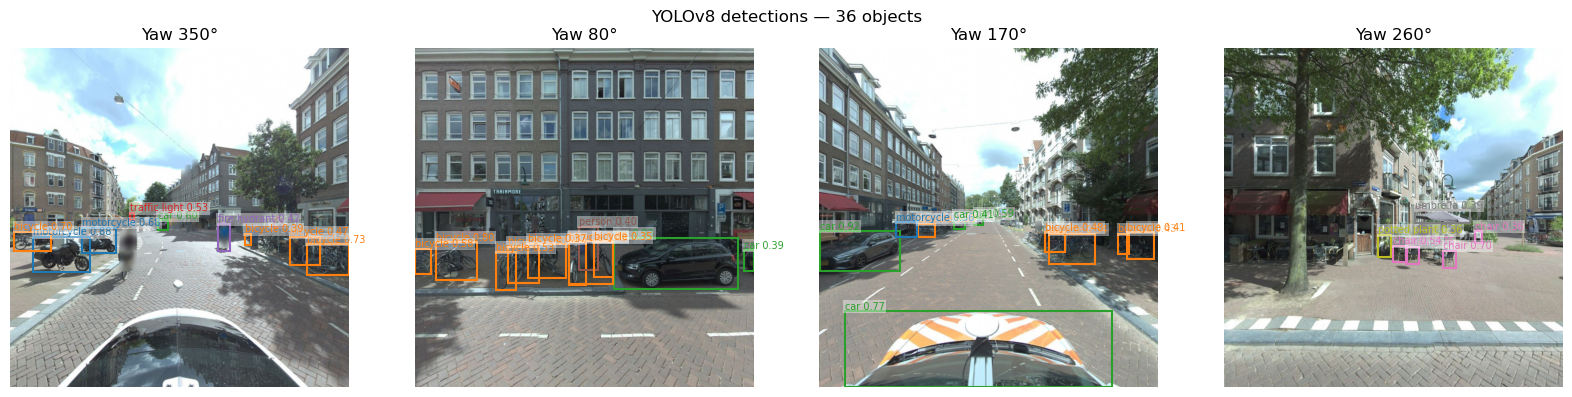

In [16]:
model = load_detector(YOLO_WEIGHTS)
detections = detect_patches(img_patches, patch_params_list, model, conf=DETECTION_CONF)
print(f"Found {len(detections)} detections.")

# Visualise bounding boxes on each patch
fig, axes = plt.subplots(1, N_PATCHES, figsize=(16, 4))
for ax, patch, pp in zip(axes, img_patches, patch_params_list):
    ax.imshow(patch)
    ax.set_title(f"Yaw {pp.yaw_deg:.0f}°")
    ax.axis("off")

colors = plt.cm.get_cmap("tab10", 10)
class_color = {}
for det in detections:
    if det.class_name not in class_color:
        class_color[det.class_name] = colors(len(class_color) % 10)
    ax = axes[det.patch_idx]
    x1, y1, x2, y2 = det.bbox_xyxy
    rect = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=1.5, edgecolor=class_color[det.class_name], facecolor="none"
    )
    ax.add_patch(rect)
    ax.text(x1, y1 - 3, f"{det.class_name} {det.confidence:.2f}",
            color=class_color[det.class_name], fontsize=7,
            bbox=dict(facecolor="white", alpha=0.4, pad=1, edgecolor="none"))

plt.suptitle(f"YOLOv8 detections — {len(detections)} objects")
plt.tight_layout()
plt.show()


## Step D — Backproject detections to ground plane

In [17]:
ground_z = pose.z - CAM_HEIGHT_M   # camera is ~2 m above road surface

for det in detections:
    pp = patch_params_list[det.patch_idx]
    x1, y1, x2, y2 = det.bbox_xyxy
    # Bottom-center of the bbox → object-ground contact point
    result = detection_to_ground_position((x1, y2, x2, y2), pp, pose, ground_z)
    if result is not None:
        det.x_rd, det.y_rd = result

positioned = [d for d in detections if d.x_rd is not None]
print(f"{len(positioned)}/{len(detections)} detections projected to ground.")


36/36 detections projected to ground.


## Step E — Cross-reference with LiDAR clusters

In [18]:
if len(cluster_df) > 0:
    label_col = "final_label" if cluster_df.get("final_label", pd.Series()).notna().any() else "label"
    matches, unmatched_dets, unmatched_clusters = cross_reference(
        positioned, cluster_df, match_radius_m=MATCH_RADIUS_M
    )

    print(f"Matched:           {len(matches)} detections")
    print(f"Unmatched (pano):  {len(unmatched_dets)} — potential LiDAR misses")
    print(f"Unmatched (LiDAR): {len(unmatched_clusters)} clusters — not seen in panorama")

    mismatches = [
        (m["detection"].class_name,
         Labels.STR_DICT.get(int(m["lidar_cluster"][label_col]), "?"),
         round(m["distance_m"], 2))
        for m in matches
        if not m["label_match"]
    ]
    if mismatches:
        mismatch_df = pd.DataFrame(mismatches, columns=["pano_class", "lidar_label", "dist_m"])
        print("\nLabel mismatches:")
        display(mismatch_df)
    else:
        print("No label mismatches.")
else:
    print("No cluster inventory — skipping cross-reference.")


Matched:           7 detections
Unmatched (pano):  29 — potential LiDAR misses
Unmatched (LiDAR): 56 clusters — not seen in panorama

Label mismatches:


,pano_class,lidar_label,dist_m
0,car,Tree,2.29
1,bicycle,Tree,2.41
2,bicycle,Tree,0.83
3,bicycle,Tree,0.95
4,person,Tree,2.24
5,bicycle,Tree,2.06
6,bicycle,Tree,1.48


## Step F — Export detections as GeoJSON

In [19]:
out_dir = config.CLUSTERS_DIR / TILECODE
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / f"panorama_detections_{TILECODE}.geojson"

gdf = detections_to_geodataframe(positioned)
gdf.to_crs("EPSG:4326").to_file(str(out_path), driver="GeoJSON")
print(f"Saved {len(gdf)} detections to {out_path}")


Saved 36 detections to data/output/clusters/120300_489300/panorama_detections_120300_489300.geojson


## Multi-camera detection map

Runs YOLO on **all** panoramas in the tile, projects each detection to the ground plane
(using the bottom edge of the bounding box as the object-ground contact point), and
draws a spatial map with:

- **Tile polygon** — the LiDAR point cloud footprint from the bbox GeoJSON
- **Camera positions** — numbered circles with heading arrows; each camera has its own colour
- **Rays** — dashed lines from camera to projected detection (show viewing direction)
- **Detection markers** — coloured by YOLO class, labelled with class name and confidence

Running YOLO on 9 tiles…

  120300_489300: 5 cameras, 153 detections  → data/output/clusters/120300_489300/panorama_detections_120300_489300.geojson
  120300_488900: 2 cameras, 40 detections  → data/output/clusters/120300_488900/panorama_detections_120300_488900.geojson
  120700_489300: 3 cameras, 35 detections  → data/output/clusters/120700_489300/panorama_detections_120700_489300.geojson
  119900_489300: 3 cameras, 68 detections  → data/output/clusters/119900_489300/panorama_detections_119900_489300.geojson
  120300_489700: 3 cameras, 87 detections  → data/output/clusters/120300_489700/panorama_detections_120300_489700.geojson
  121100_484900: 3 cameras, 89 detections  → data/output/clusters/121100_484900/panorama_detections_121100_484900.geojson
  121500_484900: no panoramas.json — skipping (run notebook 8 first)
  121100_485300: 4 cameras, 111 detections  → data/output/clusters/121100_485300/panorama_detections_121100_485300.geojson
  121500_485300: 3 cameras, 101 detections  → dat

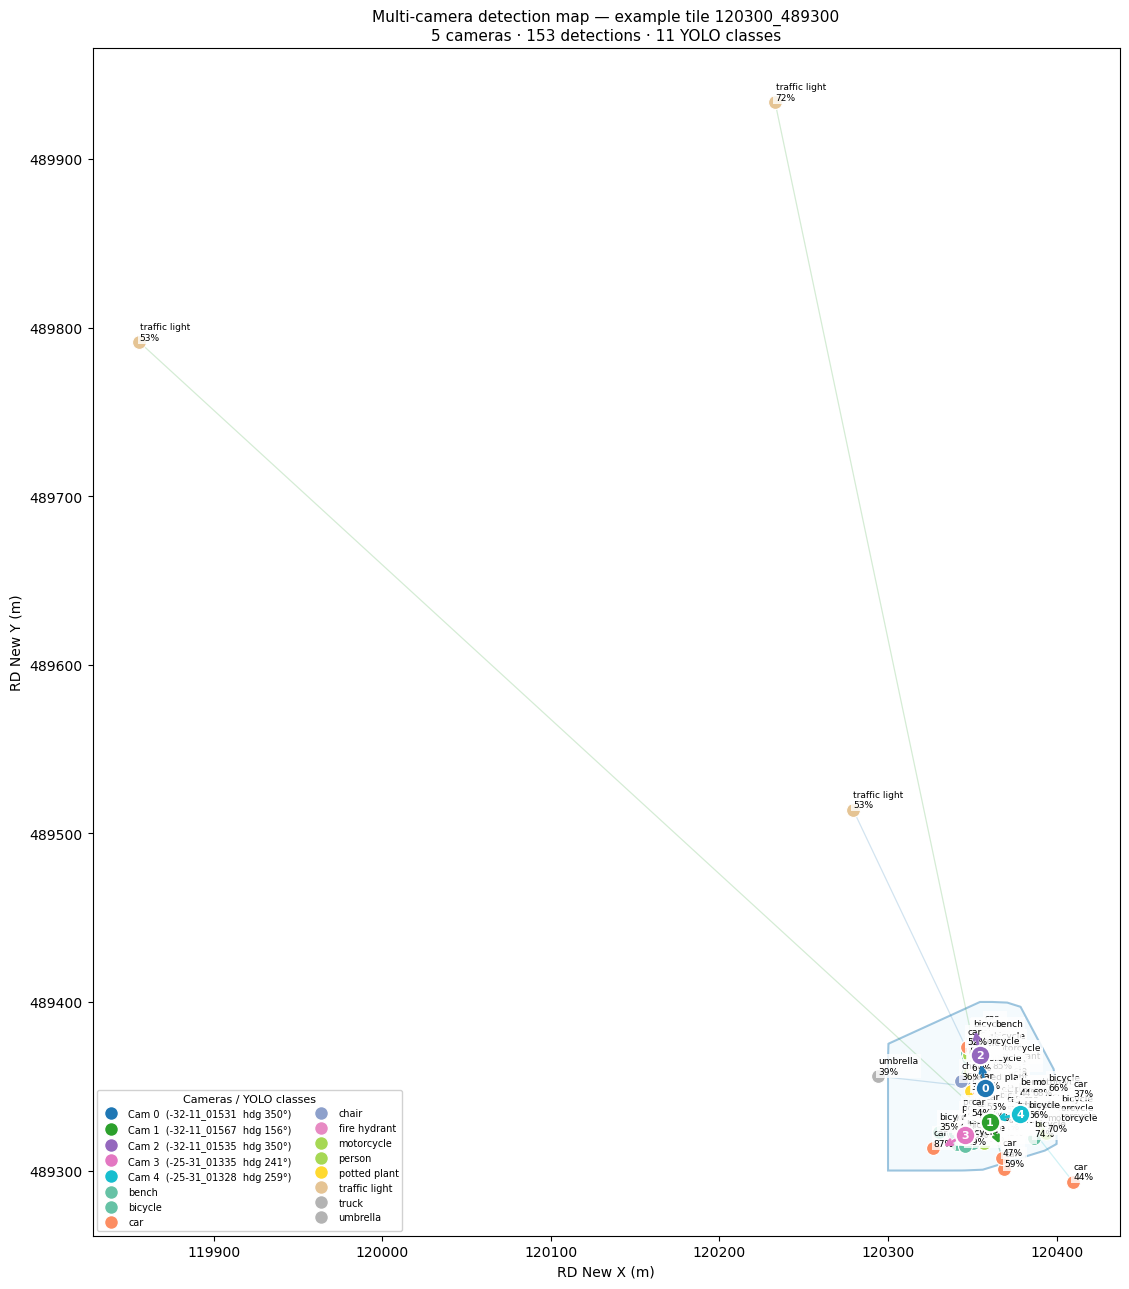

In [20]:
import json as _json
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.lines import Line2D

# ── Batch: run YOLO + export GeoJSON for every tile ──────────────────────────
print(f"Running YOLO on {len(TILECODES)} tiles…\n")

ALL_TILE_RESULTS = {}   # tilecode -> [(pose_dict, CameraPose, [Detection, ...])]

for _tilecode in TILECODES:
    _pano_list = PANO_DIR / _tilecode / "panoramas.json"
    if not _pano_list.exists():
        print(f"  {_tilecode}: no panoramas.json — skipping (run notebook 8 first)")
        continue

    with open(_pano_list) as _f:
        _tile_poses = json.load(_f)

    _cam_results = []
    for pose_d in _tile_poses:
        cam_pose = CameraPose(
            x_rd=pose_d["x_rd"], y_rd=pose_d["y_rd"], z=pose_d["z_wgs84"],
            heading=pose_d["heading"], pitch=pose_d["pitch"],
            roll=pose_d.get("roll", 0.0),
        )
        img_p = PANO_DIR / _tilecode / f"{pose_d['pano_id']}.jpg"
        if not img_p.exists():
            continue

        img_i = np.array(Image.open(img_p).convert("RGB"))
        pps = make_patches(
            heading_deg=cam_pose.heading, fov_h_deg=FOV_H,
            out_hw=PATCH_SIZE, n_horizontal=N_PATCHES,
            pitch_deg=0.0, img_shape=img_i.shape,
        )
        patches_i = [equirect_to_perspective(img_i, pp) for pp in pps]
        dets_i    = detect_patches(patches_i, pps, model, conf=DETECTION_CONF)

        gz = cam_pose.z - CAM_HEIGHT_M
        for det in dets_i:
            x1, y1, x2, y2 = det.bbox_xyxy
            result = detection_to_ground_position(
                (x1, y2, x2, y2), pps[det.patch_idx], cam_pose, gz
            )
            if result is not None:
                det.x_rd, det.y_rd = result

        valid = [d for d in dets_i if d.x_rd is not None]
        _cam_results.append((pose_d, cam_pose, valid))

    ALL_TILE_RESULTS[_tilecode] = _cam_results

    _all_dets = [d for _, _, dets in _cam_results for d in dets]
    print(f"  {_tilecode}: {len(_cam_results)} cameras, {len(_all_dets)} detections", end="")

    if _all_dets:
        _out_dir = config.CLUSTERS_DIR / _tilecode
        _out_dir.mkdir(parents=True, exist_ok=True)
        _out_path = _out_dir / f"panorama_detections_{_tilecode}.geojson"
        _gdf = detections_to_geodataframe(_all_dets)
        _gdf.to_crs("EPSG:4326").to_file(str(_out_path), driver="GeoJSON")
        print(f"  → {_out_path}")
    else:
        print()

grand_total = sum(
    len(dets) for res in ALL_TILE_RESULTS.values() for _, _, dets in res
)
print(f"\nDone. {grand_total} detections across {len(ALL_TILE_RESULTS)} tiles.")

# Make CAM_RESULTS point at the example tile so the comparison cell below works
CAM_RESULTS = ALL_TILE_RESULTS.get(TILECODE, [])

# ── Multi-camera detection map for the example tile ───────────────────────────
total_dets_ex = sum(len(dets) for _, _, dets in CAM_RESULTS)

fig, ax = plt.subplots(figsize=(13, 13))

bbox_path = config.BBOX_DIR / f"bbox_{TILECODE}.geojson"
if bbox_path.exists():
    with open(bbox_path) as _f:
        _gj = _json.load(_f)
    _coords = np.array(_gj["features"][0]["geometry"]["coordinates"][0])
    ax.add_patch(MplPolygon(
        _coords, closed=True,
        facecolor="#e8f4fb", edgecolor="#2980b9", linewidth=1.5, alpha=0.45, zorder=1,
    ))
else:
    _parts = TILECODE.split("_")
    ax.add_patch(plt.Rectangle(
        (float(_parts[0]), float(_parts[1])), 50, 50,
        fill=False, edgecolor="#2980b9", linewidth=1.5, zorder=1,
    ))

cam_colors = plt.cm.tab10(np.linspace(0, 0.9, max(len(CAM_RESULTS), 1)))
all_classes = sorted({d.class_name for _, _, dets in CAM_RESULTS for d in dets})
cls_pal     = plt.cm.Set2(np.linspace(0, 1, max(len(all_classes), 1)))
cls_color   = {cls: cls_pal[i] for i, cls in enumerate(all_classes)}

for cam_idx, (pose_d, cam_pose, dets) in enumerate(CAM_RESULTS):
    cx, cy = cam_pose.x_rd, cam_pose.y_rd
    color  = cam_colors[cam_idx]
    ax.plot(cx, cy, "o", color=color, markersize=14, zorder=12,
            markeredgecolor="white", markeredgewidth=1.5)
    ax.text(cx, cy, str(cam_idx), ha="center", va="center",
            fontsize=8, fontweight="bold", color="white", zorder=13)
    h_rad = math.radians(cam_pose.heading)
    ax.annotate(
        "", xy=(cx + math.sin(h_rad)*16, cy + math.cos(h_rad)*16),
        xytext=(cx, cy),
        arrowprops=dict(arrowstyle="->", color=color, lw=2.0), zorder=11,
    )
    for det in dets:
        dc = cls_color.get(det.class_name, "gray")
        ax.plot([cx, det.x_rd], [cy, det.y_rd],
                color=color, alpha=0.2, linewidth=0.9, zorder=2)
        ax.scatter(det.x_rd, det.y_rd, s=100, color=[dc],
                   edgecolor="white", linewidth=0.8, zorder=8)
        ax.text(
            det.x_rd + 0.3, det.y_rd + 0.2,
            f"{det.class_name}\n{det.confidence:.0%}",
            fontsize=6.5, zorder=9, va="bottom",
            bbox=dict(facecolor="white", alpha=0.80, edgecolor="none", pad=1.5),
        )

cam_handles = [
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor=cam_colors[i], markersize=10,
           label=f"Cam {i}  ({p['pano_id'][-12:]}  hdg {p['heading']:.0f}°)")
    for i, (p, _, _) in enumerate(CAM_RESULTS)
]
cls_handles = [
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor=cls_color[cls], markersize=10, label=cls)
    for cls in all_classes
]
ax.legend(
    handles=cam_handles + cls_handles,
    title="Cameras / YOLO classes", fontsize=7, title_fontsize=8,
    loc="lower left", framealpha=0.9, ncol=2,
)
ax.autoscale()
ax.set_aspect("equal")
ax.set_xlabel("RD New X (m)", fontsize=10)
ax.set_ylabel("RD New Y (m)", fontsize=10)
ax.set_title(
    f"Multi-camera detection map — example tile {TILECODE}\n"
    f"{len(CAM_RESULTS)} cameras · {total_dets_ex} detections · {len(all_classes)} YOLO classes",
    fontsize=11,
)
plt.tight_layout()
plt.show()

## YOLO ↔ LiDAR DBSCAN comparison map

Spatially overlays all DBSCAN clusters from notebook 4 with all YOLO detections from the multi-camera
sweep. Circles are the LiDAR clusters (sized by `area_m2`), triangles/diamonds are YOLO detections.
Dashed lines connect matched pairs (nearest cluster within 3 m with a compatible label).

- **Filled diamond** — YOLO detection matched to a LiDAR cluster
- **Outlined triangle** — YOLO detection with no matching cluster (potential LiDAR miss)
- **Bright-edged circle** — LiDAR cluster matched by YOLO
- **Dim circle** — LiDAR cluster not detected in any panorama (occluded, parked, or out of YOLO vocabulary)

DBSCAN clusters: 57
_lbl
Unknown            40
Tree               10
Car                 5
Streetlight         1
Large container     1

YOLO detections (multi-camera (5 cams)): 153
class_name
bicycle          69
car              44
motorcycle       16
potted plant      7
chair             4
traffic light     3
person            3
truck             3
bench             2
fire hydrant      1
umbrella          1

Matched pairs:         32
  Labels agree:        1
  Labels differ:       31
YOLO-only detections:  121
LiDAR-only clusters:   41


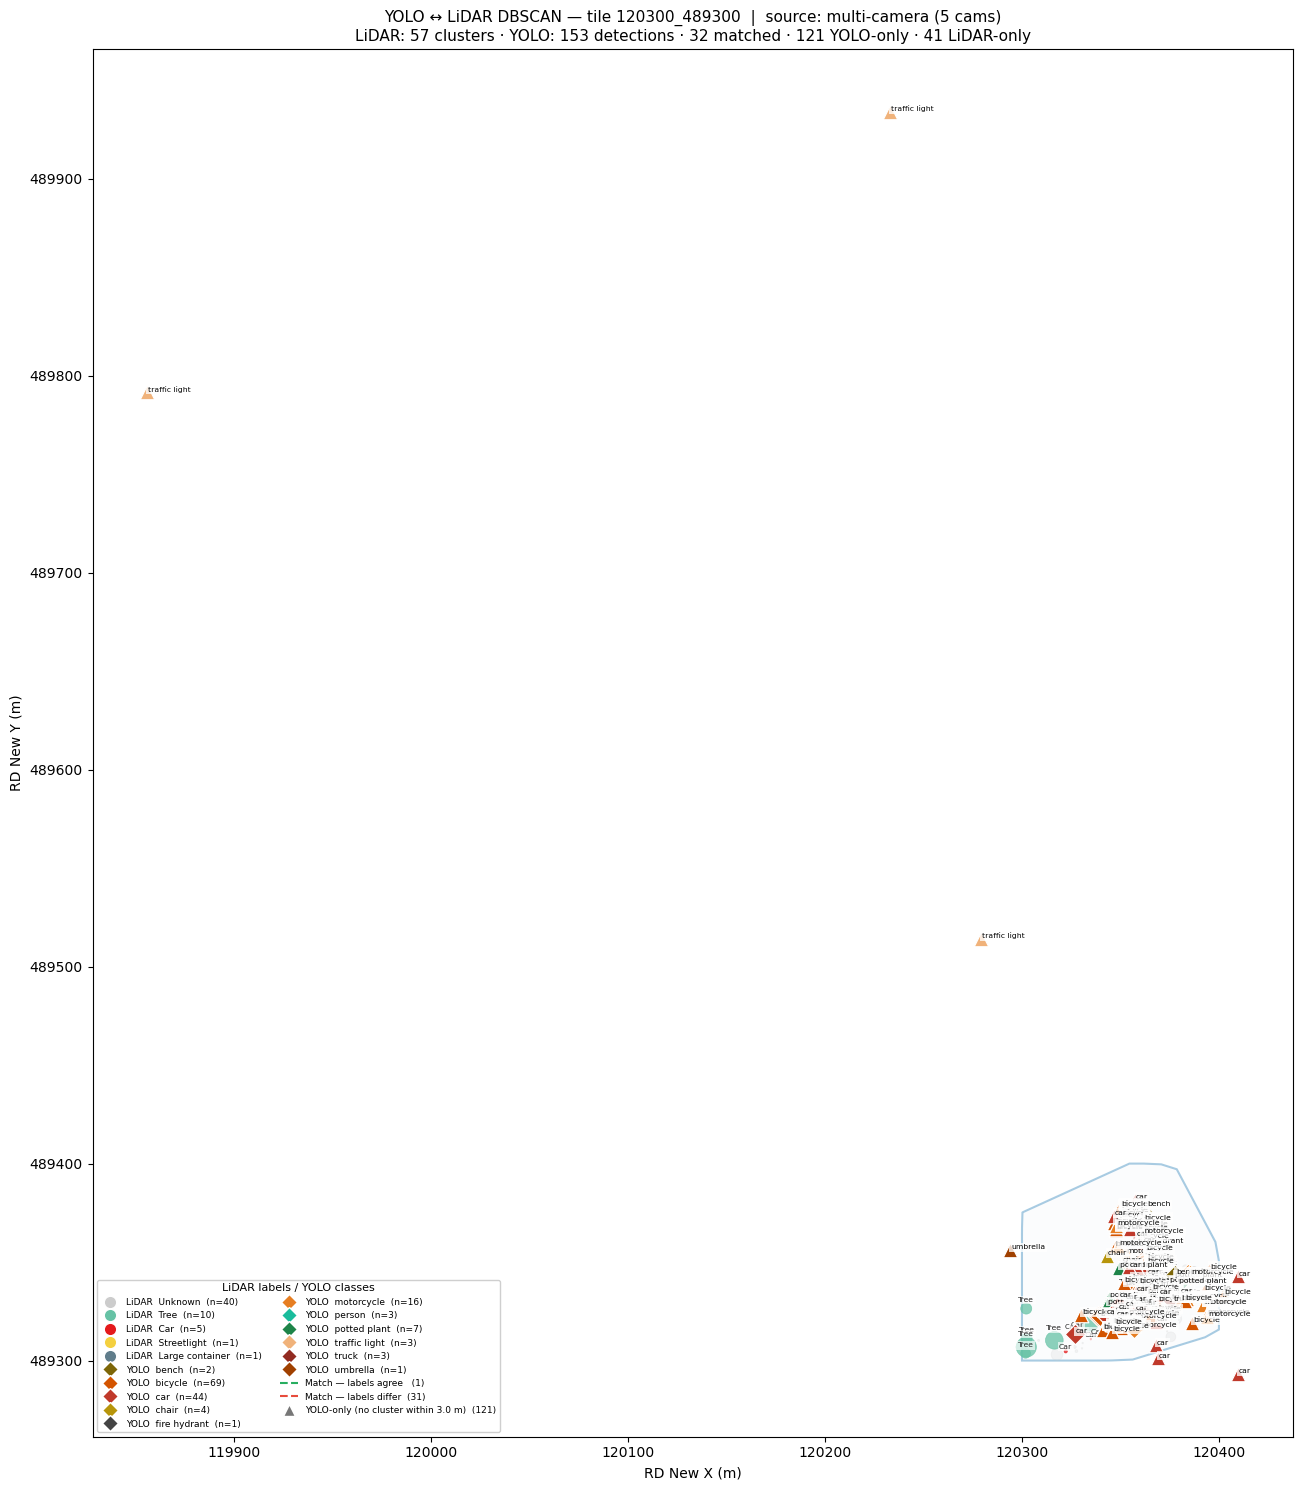


Matched pairs (sorted by distance):


,YOLO class,LiDAR label,agree,dist_m
19,bicycle,Unknown,✗,0.4
27,potted plant,Unknown,✗,0.7
3,bicycle,Tree,✗,0.8
11,motorcycle,Unknown,✗,0.8
29,bench,Unknown,✗,0.9
4,bicycle,Tree,✗,0.9
12,potted plant,Unknown,✗,1.0
22,car,Tree,✗,1.1
18,bicycle,Unknown,✗,1.1
23,car,Tree,✗,1.2


In [21]:
import json as _json2
import geopandas as gpd
from shapely.geometry import Point as _SPoint
from matplotlib.patches import Circle as MplCircle, Polygon as MplPolygon2
from matplotlib.lines import Line2D

# ── Load DBSCAN inventory ─────────────────────────────────────────────────────
_inv = config.CLUSTERS_DIR / f"inventory_{TILECODE}.csv"
if not _inv.exists():
    _inv = config.CLUSTERS_DIR / TILECODE / f"inventory_{TILECODE}.csv"
if not _inv.exists():
    raise FileNotFoundError("No inventory found — run notebooks 3.5 and 4 first.")

c_df = pd.read_csv(_inv)
_lbl_col = "final_label" if c_df.get("final_label", pd.Series()).notna().any() else "label"
c_df["_lbl"] = c_df[_lbl_col].fillna(0).astype(int)
print(f"DBSCAN clusters: {len(c_df)}")
print(c_df["_lbl"].map(Labels.STR_DICT).value_counts().to_string())

# ── Load YOLO detections ──────────────────────────────────────────────────────
# Use multi-camera CAM_RESULTS (cell above) when available — more complete coverage.
# Falls back to the single-panorama GeoJSON saved in step F.
if "CAM_RESULTS" in dir() and CAM_RESULTS:
    _rows = []
    for _pd, _cp, _dets in CAM_RESULTS:
        for _d in _dets:
            _rows.append({
                "class_name": _d.class_name,
                "upsw_label": getattr(_d, "upsw_label", None),
                "confidence": _d.confidence,
                "geometry":   _SPoint(_d.x_rd, _d.y_rd),
            })
    y_gdf = gpd.GeoDataFrame(_rows, crs="EPSG:28992")
    _src = f"multi-camera ({len(CAM_RESULTS)} cams)"
else:
    _det_path = config.CLUSTERS_DIR / TILECODE / f"panorama_detections_{TILECODE}.geojson"
    if not _det_path.exists():
        raise FileNotFoundError("No panorama detections — run step C–F or the multi-camera map first.")
    y_gdf = gpd.read_file(_det_path).to_crs("EPSG:28992")
    _src = "single panorama (GeoJSON)"

print(f"\nYOLO detections ({_src}): {len(y_gdf)}")
print(y_gdf["class_name"].value_counts().to_string())

# ── Spatial match: each YOLO detection → nearest cluster within threshold ─────
MATCH_R_M = 3.0
from utils.detection import COCO_TO_UPSW

matched_y  = set()
matched_c  = set()
match_rows = []   # (y_idx, c_df_idx, dist_m, yolo_class, cluster_label, labels_agree)

for yi, yrow in y_gdf.iterrows():
    px, py = yrow.geometry.x, yrow.geometry.y
    dists  = np.hypot(c_df["centroid_x"].values - px,
                      c_df["centroid_y"].values - py)
    best_i = int(np.argmin(dists))
    best_d = float(dists[best_i])
    if best_d <= MATCH_R_M:
        c_lbl  = int(c_df.iloc[best_i]["_lbl"])
        y_upsw = COCO_TO_UPSW.get(yrow["class_name"], -1)
        match_rows.append((yi, best_i, best_d, yrow["class_name"],
                           c_lbl, y_upsw == c_lbl))
        matched_y.add(yi)
        matched_c.add(best_i)

print(f"\nMatched pairs:         {len(match_rows)}")
print(f"  Labels agree:        {sum(r[5] for r in match_rows)}")
print(f"  Labels differ:       {sum(not r[5] for r in match_rows)}")
print(f"YOLO-only detections:  {len(y_gdf) - len(matched_y)}")
print(f"LiDAR-only clusters:   {len(c_df) - len(matched_c)}")

# ── Colour maps ───────────────────────────────────────────────────────────────
LIDAR_COLORS = {
    0:  "#cccccc",  9:  "#a0856a",  10: "#8da0cb",
    30: "#66c2a5",  39: "#99d8c9",  40: "#e41a1c",
    44: "#ff7f00",  45: "#fdbf6f",  46: "#ff7f00",
    60: "#f4d03f",  61: "#f0e442",  62: "#56b4e9",
    65: "#984ea3",  80: "#795548",  81: "#a1887f",
    83: "#607d8b",  85: "#009e73",  88: "#d55e00",
    89: "#cc79a7",  91: "#e0aaff",  99: "#f8f8f8",
}
YOLO_COLORS = {
    "car":          "#c0392b",  "truck":       "#922b21",  "bus":       "#884ea0",
    "bicycle":      "#d35400",  "motorcycle":  "#e67e22",  "person":    "#1abc9c",
    "bench":        "#7d6608",  "chair":       "#b7950b",  "umbrella":  "#a04000",
    "potted plant": "#1e8449",  "traffic light":"#f0b27a", "stop sign": "#1a5276",
    "parking meter":"#117a65",
}

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 15))

# Tile polygon
_bpath = config.BBOX_DIR / f"bbox_{TILECODE}.geojson"
if _bpath.exists():
    with open(_bpath) as _f2:
        _gj2 = _json2.load(_f2)
    _xy2 = np.array(_gj2["features"][0]["geometry"]["coordinates"][0])
    ax.add_patch(MplPolygon2(_xy2, closed=True,
        facecolor="#f7f9fc", edgecolor="#2980b9", linewidth=1.5, alpha=0.4, zorder=0))

# ── LiDAR clusters (circles sized by area_m2) ────────────────────────────────
for ci, crow in c_df.iterrows():
    lbl    = crow["_lbl"]
    cx, cy = crow["centroid_x"], crow["centroid_y"]
    r      = min(max(np.sqrt(max(crow["area_m2"], 0.1) / np.pi), 0.4), 9.0)
    color  = LIDAR_COLORS.get(lbl, "#aaaaaa")
    is_m   = ci in matched_c
    ax.add_patch(MplCircle((cx, cy), r,
        facecolor=color, edgecolor="#111111" if is_m else color,
        linewidth=2.0 if is_m else 0.5,
        alpha=0.75 if lbl != 0 else 0.20, zorder=3))
    if lbl not in (0, 1, 9, 10, 99):
        ax.text(cx, cy + r + 0.5, Labels.STR_DICT.get(lbl, str(lbl)),
                fontsize=5.5, ha="center", color="#222", zorder=5,
                bbox=dict(facecolor="white", alpha=0.65, edgecolor="none", pad=1))

# ── YOLO detections ───────────────────────────────────────────────────────────
for yi, yrow in y_gdf.iterrows():
    px, py = yrow.geometry.x, yrow.geometry.y
    cls    = yrow["class_name"]
    yc     = YOLO_COLORS.get(cls, "#444444")
    is_m   = yi in matched_y
    ax.scatter(px, py, s=110, color=yc,
               marker="D" if is_m else "^",
               edgecolor="white", linewidth=0.9, zorder=9)
    ax.text(px + 0.4, py + 0.4, cls, fontsize=5.5, zorder=10,
            bbox=dict(facecolor="white", alpha=0.78, edgecolor="none", pad=1.2))

# ── Match lines (green = labels agree, red = disagree) ───────────────────────
for yi, ci, dist, y_cls, c_lbl, ok in match_rows:
    yrow = y_gdf.loc[yi]
    crow = c_df.iloc[ci]
    ax.plot([yrow.geometry.x, crow["centroid_x"]],
            [yrow.geometry.y, crow["centroid_y"]],
            color="#27ae60" if ok else "#e74c3c",
            alpha=0.55, linewidth=1.0, linestyle="--", zorder=6)

# ── Legend ────────────────────────────────────────────────────────────────────
lidar_handles = [
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor=LIDAR_COLORS.get(l, "#aaa"), markersize=9,
           label=f"LiDAR  {Labels.STR_DICT.get(l, str(l))}  "
                 f"(n={int((c_df['_lbl']==l).sum())})")
    for l in sorted(c_df["_lbl"].unique())
]
yolo_handles = [
    Line2D([0], [0], marker="D", color="w",
           markerfacecolor=YOLO_COLORS.get(cls, "#444"), markersize=8,
           label=f"YOLO  {cls}  (n={int((y_gdf['class_name']==cls).sum())})")
    for cls in sorted(y_gdf["class_name"].unique())
]
meta_handles = [
    Line2D([0], [0], linestyle="--", color="#27ae60",
           label=f"Match — labels agree   ({sum(r[5] for r in match_rows)})"),
    Line2D([0], [0], linestyle="--", color="#e74c3c",
           label=f"Match — labels differ  ({sum(not r[5] for r in match_rows)})"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="#777", markersize=8,
           label=f"YOLO-only (no cluster within {MATCH_R_M} m)  "
                 f"({len(y_gdf)-len(matched_y)})"),
]
ax.legend(handles=lidar_handles + yolo_handles + meta_handles,
          title="LiDAR labels / YOLO classes", fontsize=6.5, title_fontsize=8,
          loc="lower left", framealpha=0.93, ncol=2)

ax.autoscale()
ax.set_aspect("equal")
ax.set_xlabel("RD New X (m)", fontsize=10)
ax.set_ylabel("RD New Y (m)", fontsize=10)
ax.set_title(
    f"YOLO ↔ LiDAR DBSCAN — tile {TILECODE}  |  source: {_src}\n"
    f"LiDAR: {len(c_df)} clusters · YOLO: {len(y_gdf)} detections · "
    f"{len(match_rows)} matched · "
    f"{len(y_gdf)-len(matched_y)} YOLO-only · "
    f"{len(c_df)-len(matched_c)} LiDAR-only",
    fontsize=11,
)
plt.tight_layout()
plt.show()

# ── Matched-pair table ────────────────────────────────────────────────────────
if match_rows:
    _conf = pd.DataFrame(
        [(r[3], Labels.STR_DICT.get(r[4], str(r[4])),
          "✓" if r[5] else "✗", round(r[2], 1))
         for r in match_rows],
        columns=["YOLO class", "LiDAR label", "agree", "dist_m"],
    ).sort_values("dist_m")
    print("\nMatched pairs (sorted by distance):")
    display(_conf)


## YOLO ↔ BGT/Bomen Atlas comparison map

Spatially overlays the BGT/Bomen Atlas-labeled obstacles (notebook 2.5 → notebook 3 output,
`obstacles_labeled_{tilecode}.geojson`) with the YOLO panorama detections from the multi-camera
sweep above. Runs once per tile in `TILECODES`, producing an **individual plot per tile**.
Filled polygons are the BGT obstacle footprints, triangles/diamonds are YOLO detections.
Dashed lines connect matched pairs (nearest obstacle within 3 m with a compatible label).

- **Filled diamond** — YOLO detection matched to a BGT obstacle
- **Outlined triangle** — YOLO detection with no matching BGT obstacle (potential BGT/registry miss)
- **Bright-edged polygon** — BGT obstacle matched by YOLO
- **Dim polygon** — BGT obstacle not detected in any panorama (occluded, parked, or out of YOLO vocabulary)

In [ ]:
import json as _json3
import geopandas as gpd
from shapely.geometry import shape as _shape, Point as _SPoint
from matplotlib.patches import Polygon as MplPolygon3
from matplotlib.lines import Line2D
from utils.detection import COCO_TO_UPSW
from utils.sidewalk_width import fetch_voetpad_polygons

MATCH_R_M_BGT     = 3.0
_OUTLIER_BUFFER_M = 50.0   # detections projected this far outside the tile are dropped
_PAD_M            = 15.0   # map view padding around the tile bbox

LIDAR_COLORS = {
    0:  "#cccccc",  9:  "#a0856a",  10: "#8da0cb",
    30: "#66c2a5",  39: "#99d8c9",  40: "#e41a1c",
    44: "#ff7f00",  45: "#fdbf6f",  46: "#ff7f00",
    60: "#f4d03f",  61: "#f0e442",  62: "#56b4e9",
    65: "#984ea3",  80: "#795548",  81: "#a1887f",
    83: "#607d8b",  85: "#009e73",  88: "#d55e00",
    89: "#cc79a7",  91: "#e0aaff",  99: "#f8f8f8",
}
YOLO_COLORS = {
    "car":          "#c0392b",  "truck":       "#922b21",  "bus":       "#884ea0",
    "bicycle":      "#d35400",  "motorcycle":  "#e67e22",  "person":    "#1abc9c",
    "bench":        "#7d6608",  "chair":       "#b7950b",  "umbrella":  "#a04000",
    "potted plant": "#1e8449",  "traffic light":"#f0b27a", "stop sign": "#1a5276",
    "parking meter":"#117a65",
}


def compare_bgt_yolo(tilecode):
    """Load BGT obstacles + YOLO detections for one tile, match them, plot, and
    return a one-row summary dict (or None if either input is missing)."""

    bgt_path = config.OBSTACLES_DIR / f"obstacles_labeled_{tilecode}.geojson"
    if not bgt_path.exists():
        print(f"{tilecode}: no BGT obstacles found — skipping (run notebooks 2.5 and 3 first)")
        return None

    with open(bgt_path) as f:
        bgt_fc = _json3.load(f)

    # obstacles_labeled_{tilecode}.geojson has two possible schemas: notebook 3
    # (Extract 2D Obstacles) writes bare geometry + tilecode + area; notebook 3.5
    # (Manual Obstacle Labeling) later overwrites the same file with label_id /
    # existing_label / label_name once obstacles have been manually reviewed.
    # Fall back to Unknown (0) when neither field is present.
    b_rows = []
    for feat in bgt_fc["features"]:
        geom  = _shape(feat["geometry"])
        props = feat["properties"]
        lbl = props.get("label_id")
        if lbl is None:
            lbl = props.get("existing_label", 0)
        lbl = int(lbl)
        b_rows.append({
            "obstacle_idx": props.get("obstacle_idx"),
            "label_id":     lbl,
            "label_name":   props.get("label_name") or Labels.STR_DICT.get(lbl, str(lbl)),
            "area":         props.get("area", geom.area),
            "geometry":     geom,
        })

    if not b_rows:
        print(f"{tilecode}: BGT obstacles file is empty — skipping")
        return None

    b_gdf = gpd.GeoDataFrame(b_rows, crs="EPSG:28992")
    b_gdf["cx"] = b_gdf.geometry.centroid.x
    b_gdf["cy"] = b_gdf.geometry.centroid.y

    if (b_gdf["label_id"] == 0).all():
        print(f"{tilecode}: obstacles have no labels yet (run notebook 3.5 to label them) — "
              f"showing all as Unknown")

    # YOLO detections: prefer the multi-camera sweep (ALL_TILE_RESULTS, cell above),
    # fall back to the single-panorama GeoJSON saved by step F.
    cam_results = ALL_TILE_RESULTS.get(tilecode, []) if "ALL_TILE_RESULTS" in dir() else []
    if cam_results:
        rows = []
        for _pd, _cp, dets in cam_results:
            for d in dets:
                rows.append({
                    "class_name": d.class_name,
                    "upsw_label": getattr(d, "upsw_label", None),
                    "confidence": d.confidence,
                    "geometry":   _SPoint(d.x_rd, d.y_rd),
                })
        if not rows:
            print(f"{tilecode}: multi-camera sweep produced 0 detections — skipping")
            return None
        y_gdf = gpd.GeoDataFrame(rows, crs="EPSG:28992")
        src   = f"multi-camera ({len(cam_results)} cams)"
    else:
        det_path = config.CLUSTERS_DIR / tilecode / f"panorama_detections_{tilecode}.geojson"
        if not det_path.exists():
            print(f"{tilecode}: no YOLO detections found — skipping (run notebook 8/9 first)")
            return None
        y_gdf = gpd.read_file(str(det_path)).to_crs("EPSG:28992")
        if len(y_gdf) == 0:
            print(f"{tilecode}: YOLO detections file is empty — skipping")
            return None
        src   = "single panorama (GeoJSON)"

    bbox_path = config.BBOX_DIR / f"bbox_{tilecode}.geojson"
    with open(bbox_path) as f:
        gj = _json3.load(f)
    xy = np.array(gj["features"][0]["geometry"]["coordinates"][0])
    tile_x0, tile_y0 = xy[:, 0].min(), xy[:, 1].min()
    tile_x1, tile_y1 = xy[:, 0].max(), xy[:, 1].max()

    # ── BGT voetpad (footpath) polygons — plotted as background context ─────────
    voetpad_cache = Path(f"data/input/bgt/voetpad_{tilecode}.geojson")
    if voetpad_cache.exists():
        voetpad_gdf = gpd.read_file(voetpad_cache).to_crs("EPSG:28992")
    else:
        try:
            voetpad_gdf = fetch_voetpad_polygons(
                (tile_x0 - _PAD_M, tile_y0 - _PAD_M, tile_x1 + _PAD_M, tile_y1 + _PAD_M)
            )
            if len(voetpad_gdf) > 0:
                voetpad_cache.parent.mkdir(parents=True, exist_ok=True)
                voetpad_gdf.to_file(str(voetpad_cache), driver="GeoJSON")
        except Exception as e:
            print(f"{tilecode}: voetpad fetch failed ({e}) — skipping footpath background")
            voetpad_gdf = gpd.GeoDataFrame(columns=["geometry"], crs="EPSG:28992")

    # Flag detections whose ground-projected position falls far outside the tile —
    # a known limitation of bottom-of-bbox ground projection for elevated/near-horizon
    # objects (e.g. traffic lights): a small pixel error near the horizon translates
    # into a huge ground-distance error once the ray is nearly parallel to the ground.
    out_of_tile = y_gdf[
        (y_gdf.geometry.x < tile_x0 - _OUTLIER_BUFFER_M) | (y_gdf.geometry.x > tile_x1 + _OUTLIER_BUFFER_M) |
        (y_gdf.geometry.y < tile_y0 - _OUTLIER_BUFFER_M) | (y_gdf.geometry.y > tile_y1 + _OUTLIER_BUFFER_M)
    ]
    if len(out_of_tile):
        print(f"{tilecode}: ⚠ {len(out_of_tile)} YOLO detections project "
              f">{_OUTLIER_BUFFER_M:.0f} m outside the tile — excluded")
        y_gdf = y_gdf.drop(out_of_tile.index).reset_index(drop=True)

    if len(y_gdf) == 0:
        print(f"{tilecode}: no YOLO detections left after filtering outliers — skipping")
        return None

    # ── Spatial match: each YOLO detection → nearest BGT obstacle within threshold ─
    b_matched, y_matched = set(), set()
    match_rows = []   # (y_idx, b_idx, dist_m, yolo_class, bgt_label, labels_agree)

    for yi, yrow in y_gdf.iterrows():
        px, py = yrow.geometry.x, yrow.geometry.y
        dists  = np.hypot(b_gdf["cx"].values - px, b_gdf["cy"].values - py)
        best_i = int(np.argmin(dists))
        best_d = float(dists[best_i])
        if best_d <= MATCH_R_M_BGT:
            b_lbl  = int(b_gdf.iloc[best_i]["label_id"])
            y_upsw = COCO_TO_UPSW.get(yrow["class_name"], -1)
            match_rows.append((yi, best_i, best_d, yrow["class_name"], b_lbl, y_upsw == b_lbl))
            y_matched.add(yi)
            b_matched.add(best_i)

    print(f"{tilecode}: BGT {len(b_gdf)} obstacles · YOLO {len(y_gdf)} detections ({src}) · "
          f"{len(match_rows)} matched ({sum(r[5] for r in match_rows)} agree) · "
          f"{len(y_gdf)-len(y_matched)} YOLO-only · {len(b_gdf)-len(b_matched)} BGT-only")

    # ── Figure ─────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(13, 13))
    ax.add_patch(MplPolygon3(xy, closed=True,
        facecolor="#f7f9fc", edgecolor="#2980b9", linewidth=1.5, alpha=0.4, zorder=0))

    # BGT voetpad (footpath) polygons — dark grey, under the obstacle/detection layers
    for geom in voetpad_gdf.geometry:
        polys = geom.geoms if geom.geom_type == "MultiPolygon" else [geom]
        for poly in polys:
            ax.add_patch(MplPolygon3(np.array(poly.exterior.coords), closed=True,
                facecolor="#4d4d4d", edgecolor="none", alpha=0.6, zorder=1))

    for bi, brow in b_gdf.iterrows():
        lbl   = brow["label_id"]
        color = LIDAR_COLORS.get(lbl, "#aaaaaa")
        is_m  = bi in b_matched
        geom  = brow.geometry
        polys = geom.geoms if geom.geom_type == "MultiPolygon" else [geom]
        for poly in polys:
            poly_xy = np.array(poly.exterior.coords)
            ax.add_patch(MplPolygon3(poly_xy, closed=True,
                facecolor=color, edgecolor="#111111" if is_m else color,
                linewidth=1.8 if is_m else 0.5,
                alpha=0.75 if lbl != 99 else 0.20, zorder=3))
        if lbl != 99:
            ax.text(brow["cx"], brow["cy"], brow["label_name"],
                    fontsize=5.5, ha="center", color="#222", zorder=5,
                    bbox=dict(facecolor="white", alpha=0.65, edgecolor="none", pad=1))

    for yi, yrow in y_gdf.iterrows():
        px, py = yrow.geometry.x, yrow.geometry.y
        cls    = yrow["class_name"]
        yc     = YOLO_COLORS.get(cls, "#444444")
        is_m   = yi in y_matched
        ax.scatter(px, py, s=90, color=yc, marker="D" if is_m else "^",
                   edgecolor="white", linewidth=0.9, zorder=9)
        ax.text(px + 0.4, py + 0.4, cls, fontsize=5.0, zorder=10,
                bbox=dict(facecolor="white", alpha=0.78, edgecolor="none", pad=1.0))

    for yi, bi, dist, y_cls, b_lbl, ok in match_rows:
        yrow = y_gdf.loc[yi]
        brow = b_gdf.iloc[bi]
        ax.plot([yrow.geometry.x, brow["cx"]], [yrow.geometry.y, brow["cy"]],
                color="#27ae60" if ok else "#e74c3c",
                alpha=0.55, linewidth=1.0, linestyle="--", zorder=6)

    bgt_handles = [
        Line2D([0], [0], marker="s", color="w",
               markerfacecolor=LIDAR_COLORS.get(l, "#aaa"), markersize=9,
               label=f"BGT  {Labels.STR_DICT.get(l, str(l))}  (n={int((b_gdf['label_id']==l).sum())})")
        for l in sorted(b_gdf["label_id"].unique())
    ]
    yolo_handles = [
        Line2D([0], [0], marker="D", color="w",
               markerfacecolor=YOLO_COLORS.get(cls, "#444"), markersize=8,
               label=f"YOLO  {cls}  (n={int((y_gdf['class_name']==cls).sum())})")
        for cls in sorted(y_gdf["class_name"].unique())
    ]
    meta_handles = [
        Line2D([0], [0], linestyle="--", color="#27ae60",
               label=f"Match — labels agree   ({sum(r[5] for r in match_rows)})"),
        Line2D([0], [0], linestyle="--", color="#e74c3c",
               label=f"Match — labels differ  ({sum(not r[5] for r in match_rows)})"),
        Line2D([0], [0], marker="^", color="w", markerfacecolor="#777", markersize=8,
               label=f"YOLO-only (no obstacle within {MATCH_R_M_BGT} m)  ({len(y_gdf)-len(y_matched)})"),
    ]
    if len(voetpad_gdf) > 0:
        meta_handles.append(
            Line2D([0], [0], marker="s", color="w", markerfacecolor="#4d4d4d",
                   markersize=9, label="BGT voetpad (footpath)")
        )
    ax.legend(handles=bgt_handles + yolo_handles + meta_handles,
              title="BGT labels / YOLO classes", fontsize=6, title_fontsize=7.5,
              loc="lower left", framealpha=0.93, ncol=2)

    # Clip the view to the tile (+ padding) rather than autoscale — mis-projected
    # detections beyond the buffer above would otherwise blow out the axis range.
    ax.set_xlim(tile_x0 - _PAD_M, tile_x1 + _PAD_M)
    ax.set_ylim(tile_y0 - _PAD_M, tile_y1 + _PAD_M)
    ax.set_aspect("equal")
    ax.set_xlabel("RD New X (m)", fontsize=10)
    ax.set_ylabel("RD New Y (m)", fontsize=10)
    ax.set_title(
        f"YOLO ↔ BGT/Bomen Atlas — tile {tilecode}  |  source: {src}\n"
        f"BGT: {len(b_gdf)} obstacles · YOLO: {len(y_gdf)} detections · "
        f"{len(match_rows)} matched · "
        f"{len(y_gdf)-len(y_matched)} YOLO-only · "
        f"{len(b_gdf)-len(b_matched)} BGT-only",
        fontsize=10,
    )
    plt.tight_layout()
    plt.show()

    return {
        "tilecode":        tilecode,
        "bgt_obstacles":   len(b_gdf),
        "yolo_detections": len(y_gdf),
        "matched":         len(match_rows),
        "labels_agree":    sum(r[5] for r in match_rows),
        "yolo_only":       len(y_gdf) - len(y_matched),
        "bgt_only":        len(b_gdf) - len(b_matched),
    }


# ── Run the comparison for every tile in TILECODES, one plot each ────────────
_summaries = [s for tc in TILECODES if (s := compare_bgt_yolo(tc)) is not None]

if _summaries:
    print("\nSummary across tiles:")
    display(pd.DataFrame(_summaries))
